In [1]:
from google.colab import drive
drive.mount('/content/drive/')



Mounted at /content/drive/


In [2]:
import numpy as np
import pandas as pd

In [3]:
import pandas as pd

result_feature = pd.read_excel('/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity/simulation study/Feature_noise_result_all.xlsx')
result_geo = pd.read_excel('/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity/simulation study/Geo_noise_results_all.xlsx')


In [4]:
result_feature

,noise_sigma,noise_std,method,coverage,interval_score,mean_uncertainty,rmse,r2,nrmse,best_bandwidth,best_lambda
0,0.1,0.00,GeoSIMCP_ZHAO,1.0000,0.000001,0.000000,0.000000,1.000000,NaN,0.1,0.0
1,0.1,0.01,GeoSIMCP_ZHAO,0.9350,0.006249,0.002127,0.001682,-0.110869,0.076611,0.1,0.0
2,0.1,0.02,GeoSIMCP_ZHAO,0.9350,0.012498,0.004255,0.003365,-0.110869,0.076611,0.1,0.0
3,0.1,0.03,GeoSIMCP_ZHAO,0.9350,0.018747,0.006382,0.005047,-0.110869,0.076611,0.1,0.0
4,0.1,0.04,GeoSIMCP_ZHAO,0.9350,0.024996,0.008509,0.006729,-0.110869,0.076611,0.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...
481,10.0,4.00,GeoSIMCP,0.9667,0.075035,0.037023,0.019410,-0.230895,0.220482,0.1,1.0
482,10.0,5.00,GeoCP,0.9667,0.093794,0.046279,0.024263,-0.230895,0.220482,0.1,NaN
483,10.0,5.00,GeoSIMCP,0.9667,0.093794,0.046279,0.024263,-0.230895,0.220482,0.1,1.0
484,10.0,10.00,GeoCP,0.9667,0.187588,0.092557,0.048525,-0.230895,0.220482,0.1,NaN


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

# ✅ 保证保存的PDF用TrueType字体
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'DejaVu Sans'  # 也可以改成 Arial 等常用字体

# 假设 result_geo 已经读取好了
metrics = ['coverage', 'interval_score', 'mean_uncertainty','rmse']
noise_sigmas = sorted(result_geo['noise_sigma'].unique())
methods = result_geo['method'].unique()

# 给每个method指定独特的线型和marker
linestyles = {'GeoCP': '-', 'GeoSIMCP': '--', 'GeoSIMCP_ZHAO': ':'}
markers = {'GeoCP': 'o', 'GeoSIMCP': 's', 'GeoSIMCP_ZHAO': '^'}

for metric in metrics:
    fig = plt.figure(figsize=(18, 12))  # ✅ 注意 fig 用来保存

    for idx, sigma in enumerate(noise_sigmas):
        plt.subplot(3, 3, idx+1)
        subset = result_geo[(result_geo['noise_sigma'] == sigma) & (result_geo['noise_std'] >= 0.01)]

        for method in methods:
            method_subset = subset[subset['method'] == method]
            plt.plot(
                method_subset['noise_std'],
                method_subset[metric],
                label=method,
                linestyle=linestyles.get(method, '-'),
                marker=markers.get(method, 'o'),
                markersize=7,
                linewidth=2.5,
                alpha=0.9
            )

        plt.title(f'{metric} at noise_sigma={sigma}', fontsize=12)
        plt.xlabel('noise_std', fontsize=10)
        plt.ylabel(metric, fontsize=10)
        plt.grid(True)
        if idx == 0:
            plt.legend(fontsize=8)  # 只在第一个子图上放legend避免重复

    plt.suptitle(f'{metric} vs noise_std (grouped by noise_sigma)', fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # ✅ 保存为PDF，且保证是可编辑字体
    plt.savefig(f'{metric}_vs_noise_std.pdf', format='pdf')
    plt.close(fig)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

# ✅ 保证保存的PDF用TrueType字体
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'DejaVu Sans'  # 也可以改成 Arial 等常用字体

# 假设 result_geo 已经读取好了
metrics = ['coverage', 'interval_score', 'mean_uncertainty','rmse']
noise_sigmas = sorted(result_feature['noise_sigma'].unique())
methods = result_feature['method'].unique()

# 给每个method指定独特的线型和marker
linestyles = {'GeoCP': '-', 'GeoSIMCP': '--', 'GeoSIMCP_ZHAO': ':'}
markers = {'GeoCP': 'o', 'GeoSIMCP': 's', 'GeoSIMCP_ZHAO': '^'}

for metric in metrics:
    fig = plt.figure(figsize=(18, 12))  # ✅ 注意 fig 用来保存

    for idx, sigma in enumerate(noise_sigmas):
        plt.subplot(3, 3, idx+1)
        subset = result_feature[(result_feature['noise_sigma'] == sigma) & (result_feature['noise_std'] >= 0.01)]

        for method in methods:
            method_subset = subset[subset['method'] == method]
            plt.plot(
                method_subset['noise_std'],
                method_subset[metric],
                label=method,
                linestyle=linestyles.get(method, '-'),
                marker=markers.get(method, 'o'),
                markersize=7,
                linewidth=2.5,
                alpha=0.9
            )

        plt.title(f'{metric} at noise_sigma={sigma}', fontsize=12)
        plt.xlabel('noise_std', fontsize=10)
        plt.ylabel(metric, fontsize=10)
        plt.grid(True)
        if idx == 0:
            plt.legend(fontsize=8)  # 只在第一个子图上放legend避免重复

    plt.suptitle(f'{metric} vs noise_std (grouped by noise_sigma)', fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # ✅ 保存为PDF，且保证是可编辑字体
    plt.savefig(f'{metric}_feture_vs_noise_std.pdf', format='pdf')
    plt.close(fig)


,noise_sigma,noise_std,method,coverage,interval_score,mean_uncertainty,rmse,r2,nrmse,best_bandwidth,best_lambda
0,0.1,0.00,GeoSIMCP_ZHAO,1.0000,0.000001,0.000000,0.000000,1.000000,NaN,0.1,0.0
1,0.1,0.01,GeoSIMCP_ZHAO,0.9350,0.006249,0.002127,0.001682,-0.110869,0.076611,0.1,0.0
2,0.1,0.02,GeoSIMCP_ZHAO,0.9350,0.012498,0.004255,0.003365,-0.110869,0.076611,0.1,0.0
3,0.1,0.03,GeoSIMCP_ZHAO,0.9350,0.018747,0.006382,0.005047,-0.110869,0.076611,0.1,0.0
4,0.1,0.04,GeoSIMCP_ZHAO,0.9350,0.024996,0.008509,0.006729,-0.110869,0.076611,0.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...
481,10.0,4.00,GeoSIMCP,0.9667,0.075035,0.037023,0.019410,-0.230895,0.220482,0.1,1.0
482,10.0,5.00,GeoCP,0.9667,0.093794,0.046279,0.024263,-0.230895,0.220482,0.1,NaN
483,10.0,5.00,GeoSIMCP,0.9667,0.093794,0.046279,0.024263,-0.230895,0.220482,0.1,1.0
484,10.0,10.00,GeoCP,0.9667,0.187588,0.092557,0.048525,-0.230895,0.220482,0.1,NaN


## box plot

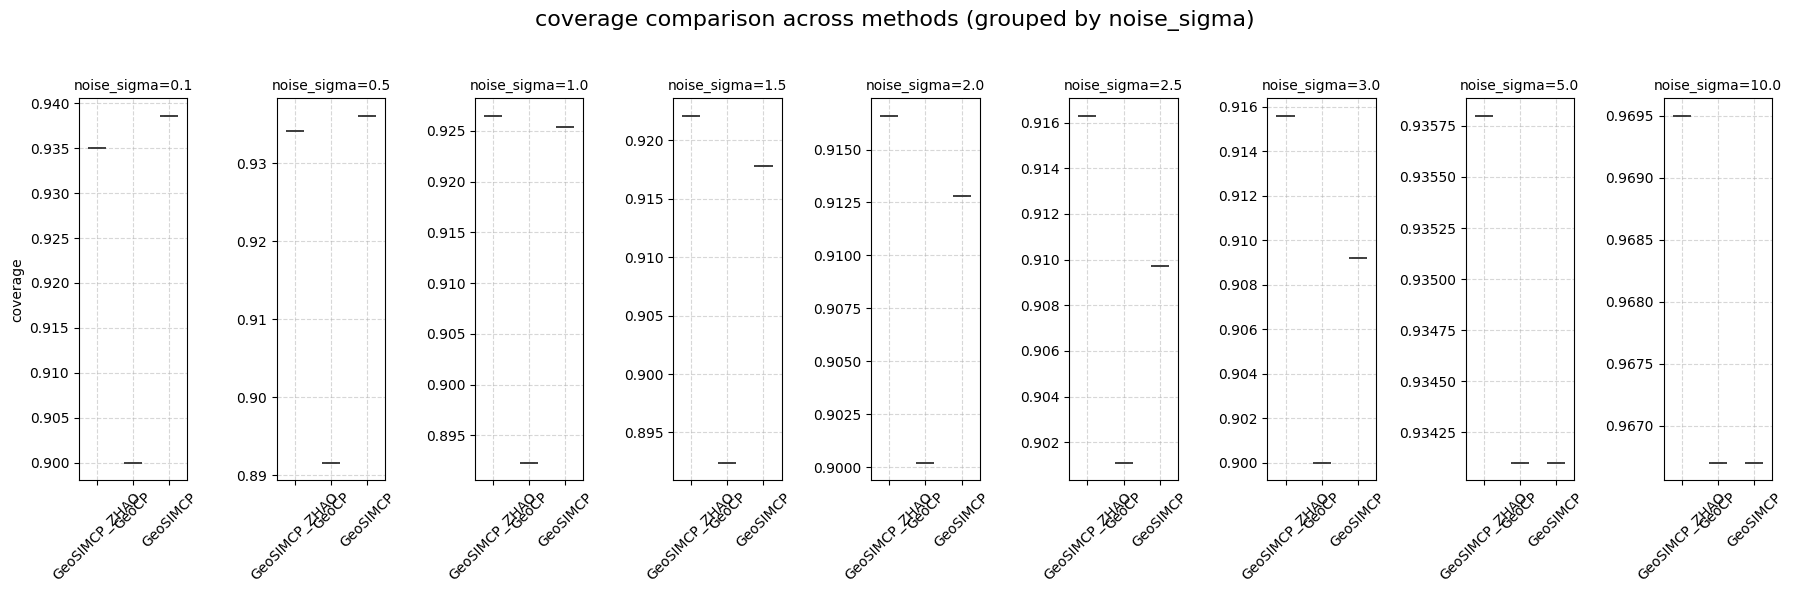

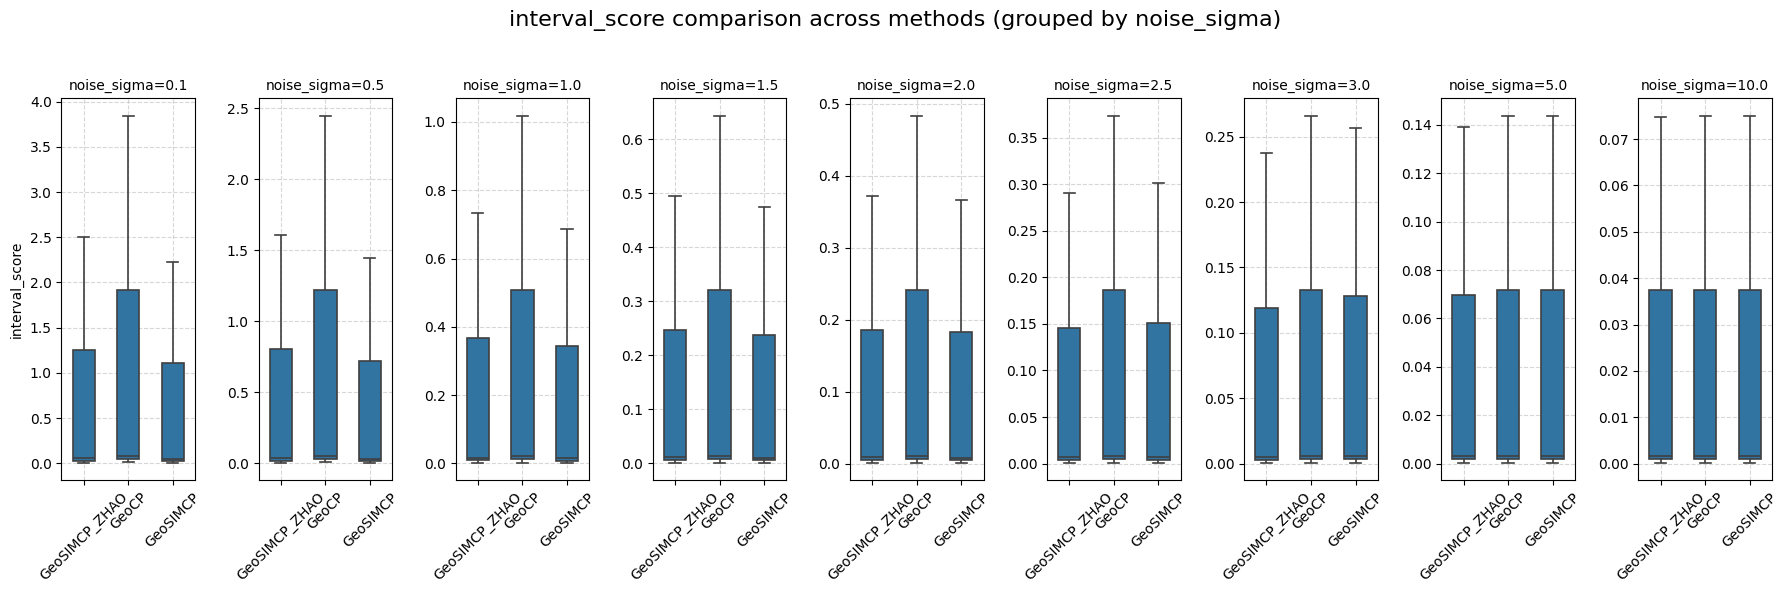

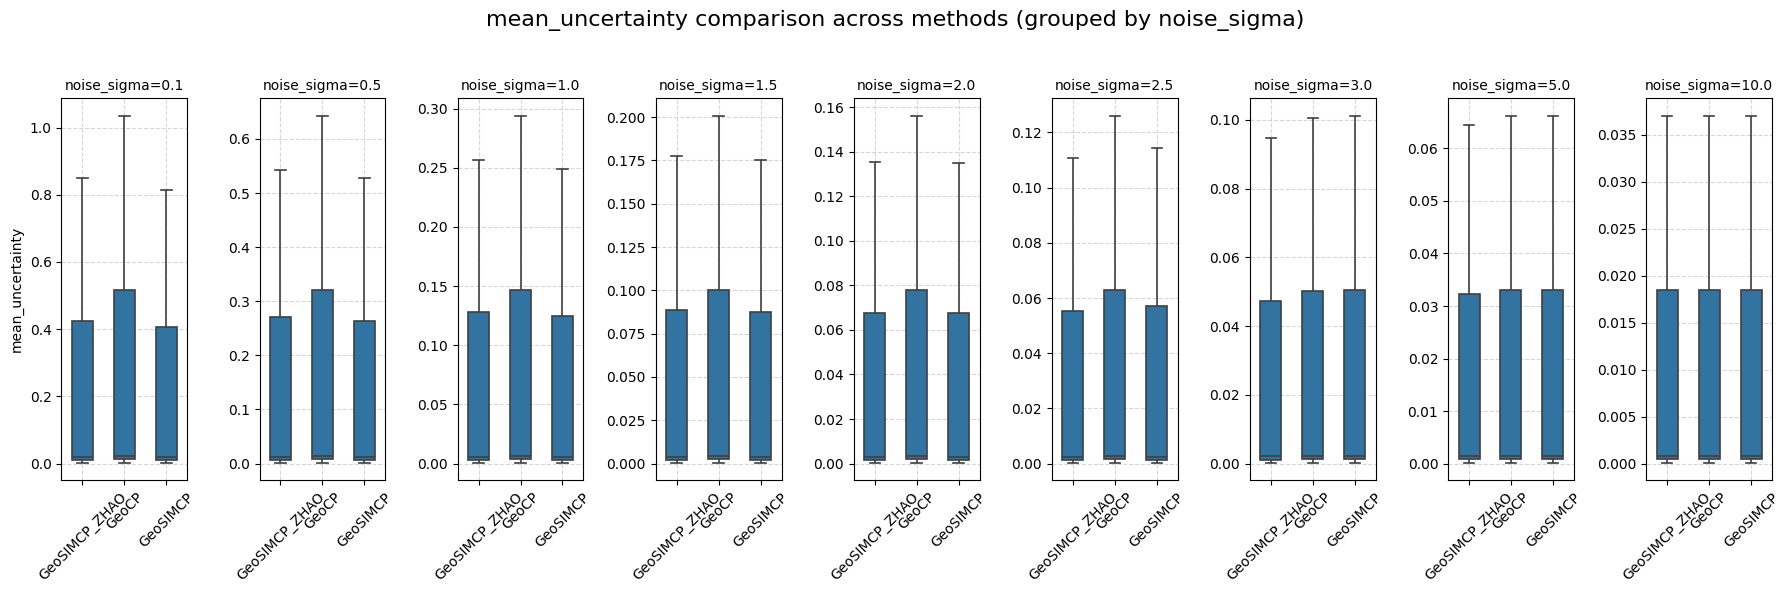

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib

# 设置PDF字体
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 假设 result_feature 已经读好了
metrics = ['coverage', 'interval_score', 'mean_uncertainty']
noise_sigmas = sorted(result_feature['noise_sigma'].unique())

for metric in metrics:
    plt.figure(figsize=(18, 6))

    for idx, sigma in enumerate(noise_sigmas):
        plt.subplot(1, len(noise_sigmas), idx+1)

        subset = result_feature[(result_feature['noise_sigma'] == sigma) & (result_feature['noise_std'] >= 0.01)]

        # 只保留要用的列
        plot_data = subset[['method', metric]].copy()
        plot_data['noise_sigma'] = sigma  # 方便标注

        sns.boxplot(
            data=plot_data,
            x='method',
            y=metric,
            showfliers=False,
            width=0.5,
            linewidth=1.2
        )

        plt.title(f'noise_sigma={sigma}', fontsize=10)
        plt.xlabel('')
        plt.ylabel(metric if idx == 0 else '')
        plt.xticks(rotation=45)
        plt.grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(f'{metric} comparison across methods (grouped by noise_sigma)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # 保存PDF
    plt.show()
    #plt.savefig(f'boxplot_{metric}_by_noise_sigma.pdf', format='pdf')
    plt.close()


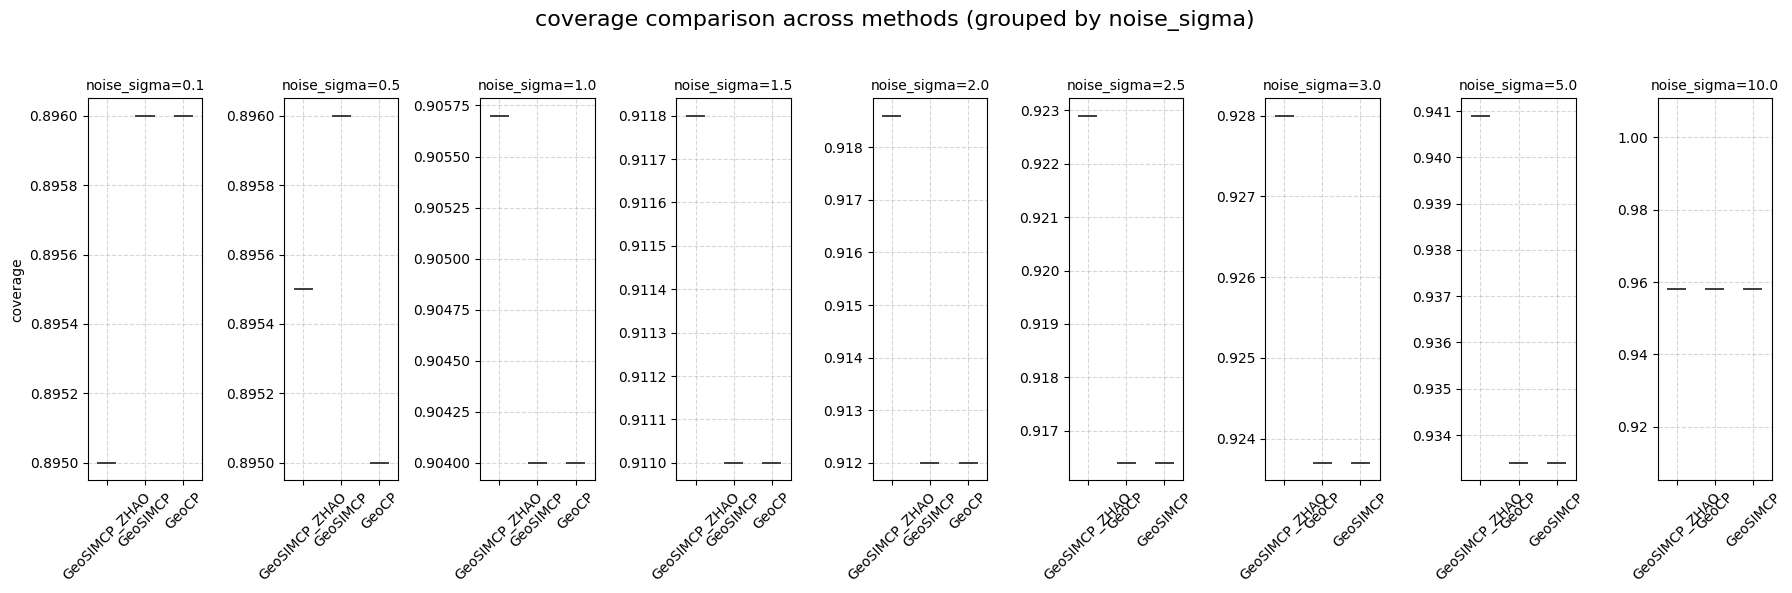

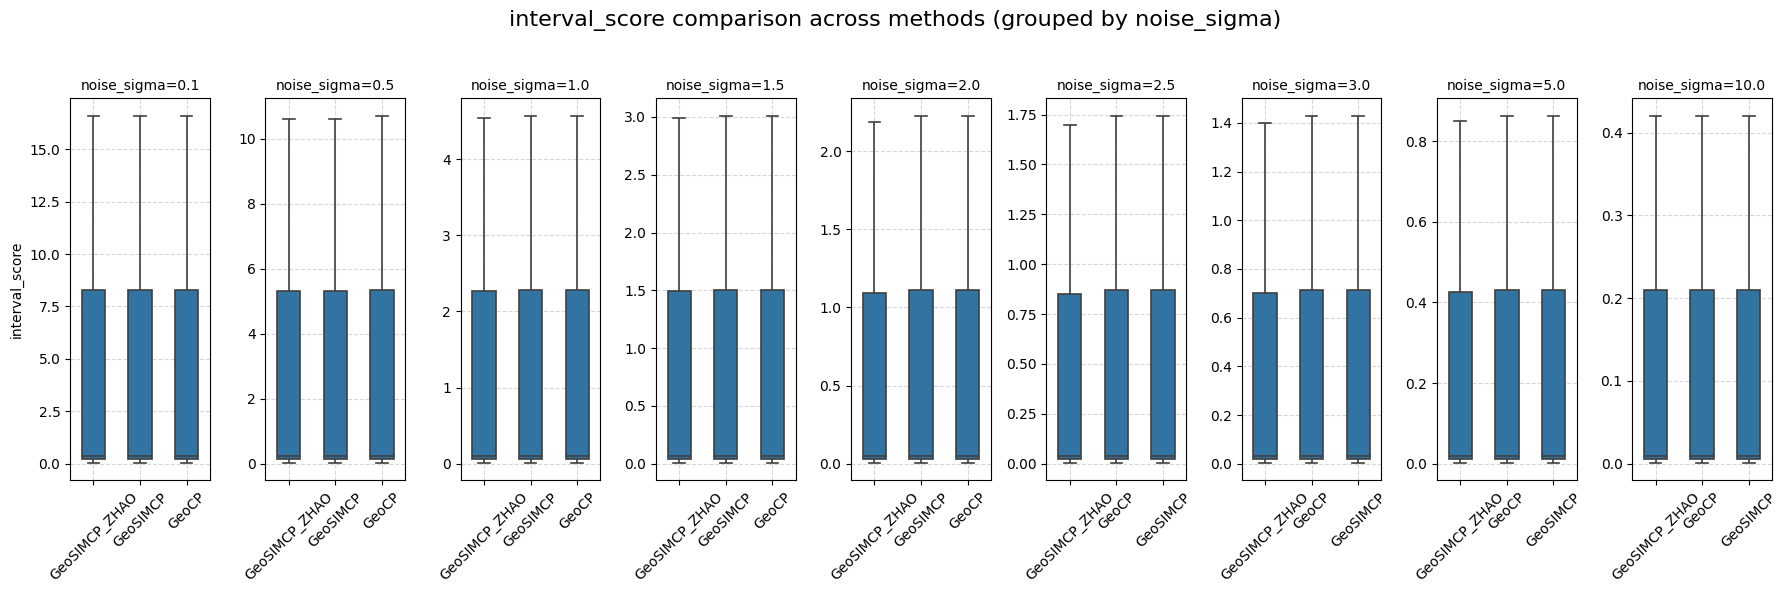

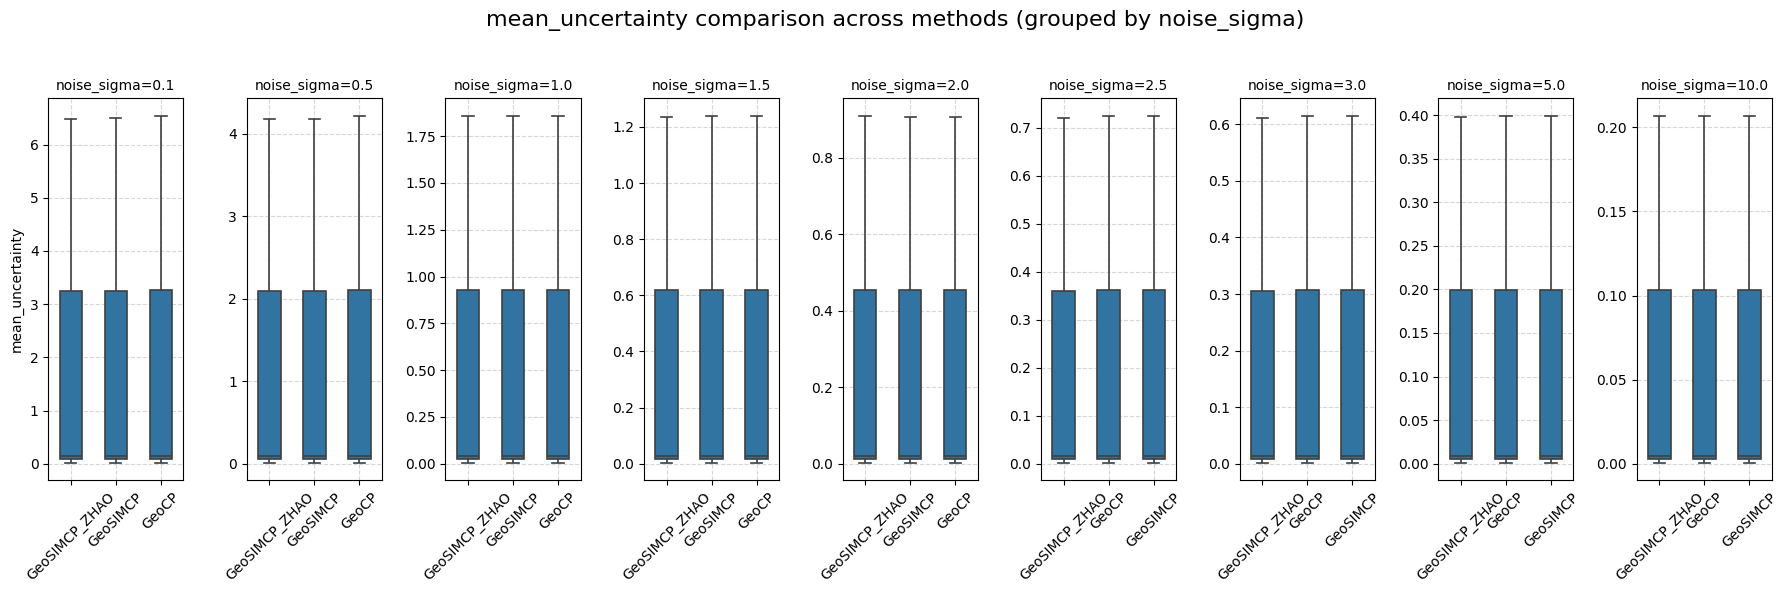

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib

# 设置PDF字体
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 假设 result_feature 已经读好了
metrics = ['coverage', 'interval_score', 'mean_uncertainty']
noise_sigmas = sorted(result_geo['noise_sigma'].unique())

for metric in metrics:
    plt.figure(figsize=(18, 6))

    for idx, sigma in enumerate(noise_sigmas):
        plt.subplot(1, len(noise_sigmas), idx+1)

        subset = result_geo[(result_geo['noise_sigma'] == sigma) & (result_geo['noise_std'] >= 0.01)]

        # 只保留要用的列
        plot_data = subset[['method', metric]].copy()
        plot_data['noise_sigma'] = sigma  # 方便标注

        sns.boxplot(
            data=plot_data,
            x='method',
            y=metric,
            showfliers=False,
            width=0.5,
            linewidth=1.2
        )

        plt.title(f'noise_sigma={sigma}', fontsize=10)
        plt.xlabel('')
        plt.ylabel(metric if idx == 0 else '')
        plt.xticks(rotation=45)
        plt.grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(f'{metric} comparison across methods (grouped by noise_sigma)', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # 保存PDF
    plt.show()
    #plt.savefig(f'boxplot_{metric}_by_noise_sigma.pdf', format='pdf')
    plt.close()
